# 🏏 Bangla Sports Sentiment Analysis using BERT
**Dataset:** Bangla Sports Comments | **Classes:** Positive / Negative

**Model:** sagorsarker/bangla-bert-base with custom classification head

**Author:** Thesis Research

In [1]:
# ✅ Check GPU — Go to: Runtime → Change runtime type → T4 GPU
import torch
if torch.cuda.is_available():
    print(f'✅ GPU Available: {torch.cuda.get_device_name(0)}')
else:
    print('⚠️  No GPU detected! Go to Runtime → Change runtime type → T4 GPU')
    print('   Training will be very slow on CPU.')

✅ GPU Available: Tesla T4


## 1. Install & Import Libraries

In [2]:
# ✅ Step 1: Install required libraries
!pip install transformers torch scikit-learn pandas numpy matplotlib seaborn openpyxl wordcloud tqdm -q

In [3]:
# ✅ Step 2: Upload your Excel dataset
from google.colab import files
import io

print('📂 Please upload: Bangla_Sports_Sentiment_Analysis_Dataset.xlsx')
uploaded = files.upload()

# Get the uploaded filename
DATASET_FILE = list(uploaded.keys())[0]
print(f'✅ File uploaded: {DATASET_FILE}')

📂 Please upload: Bangla_Sports_Sentiment_Analysis_Dataset.xlsx


Saving Bangla_Sports_Sentiment_Analysis_Dataset.xlsx to Bangla_Sports_Sentiment_Analysis_Dataset.xlsx
✅ File uploaded: Bangla_Sports_Sentiment_Analysis_Dataset.xlsx


In [4]:
import warnings
warnings.filterwarnings('ignore')

import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from transformers import (
    BertTokenizer,
    BertModel,
    get_linear_schedule_with_warmup
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)

from tqdm.auto import tqdm

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Using device: {device}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

✅ Using device: cuda
   GPU: Tesla T4


## 2. Load & Explore Dataset

In [5]:
# ✅ Step 3: Load Dataset
import pandas as pd

df = pd.read_excel(DATASET_FILE)

print('=' * 55)
print('       DATASET OVERVIEW')
print('=' * 55)
print(f'Total Rows     : {len(df):,}')
print(f'Total Columns  : {df.shape[1]}')
print(f'Columns        : {df.columns.tolist()}')
print()
print(df.head())


       DATASET OVERVIEW
Total Rows     : 82,611
Total Columns  : 3
Columns        : ['Comment ', 'Category', 'Cleaned_Text']

                                            Comment   Category  \
0                  মনে হয় পাড়া-মহল্লার খেলা দেখছি।  Positive   
1       বাংলাদেশের ফুটবল না খেলে কুত কুত খেললেই পারে  Positive   
2                বাংলাদেশের দামরা ছেলে গুলো কি খেলছে  Positive   
3   সুফল সুমন রেজা  মতিন মিয়া এগুলা বল রাখতেই পারেনা  Positive   
4  খারাপ লাগে তখন যখন,,,একজন বল বাস করে গোলের দিক...  Positive   

                                        Cleaned_Text  
0                        মন হয় পাড়া মহল্ল খেলা দেখ  
1                  বাংলাদেশ ফুটবল খালা কুত কুত খেললে  
2                             বাংলাদেশ দাম ছালা  খেল  
3     সুফল সুমন রেজা মতিন মিয়া এগুলা বল রাখতে পারেনা  
4  খারাপ লাগ যখন একজন বল বাস গোল ছোর প্লেয় সামন য...  


In [6]:
# ── Basic Stats ───────────────────────────────────────────────────────────────
print('\n── Missing Values ──')
print(df.isnull().sum())

print('\n── Category Distribution ──')
print(df['Category'].value_counts())
print(f'\nClass Balance Ratio: {df["Category"].value_counts()[0] / df["Category"].value_counts()[1]:.3f}')


── Missing Values ──
Comment           5
Category          0
Cleaned_Text    341
dtype: int64

── Category Distribution ──
Category
Negative    41355
Positive    41256
Name: count, dtype: int64

Class Balance Ratio: 1.002


In [7]:
# ── Data Cleaning ─────────────────────────────────────────────────────────────
df = df.dropna(subset=['Comment ', 'Category'])
df = df.rename(columns={'Comment ': 'Comment'})
df['Comment'] = df['Comment'].astype(str).str.strip()
df = df[df['Comment'].str.len() > 3]  # remove very short / empty
df = df.reset_index(drop=True)

# Encode labels: Positive=1, Negative=0
df['label'] = df['Category'].map({'Positive': 1, 'Negative': 0})

print(f'✅ Clean dataset size: {len(df):,}')
print(df['label'].value_counts())

✅ Clean dataset size: 82,145
label
0    41073
1    41072
Name: count, dtype: int64


## 3. Exploratory Data Analysis (EDA)

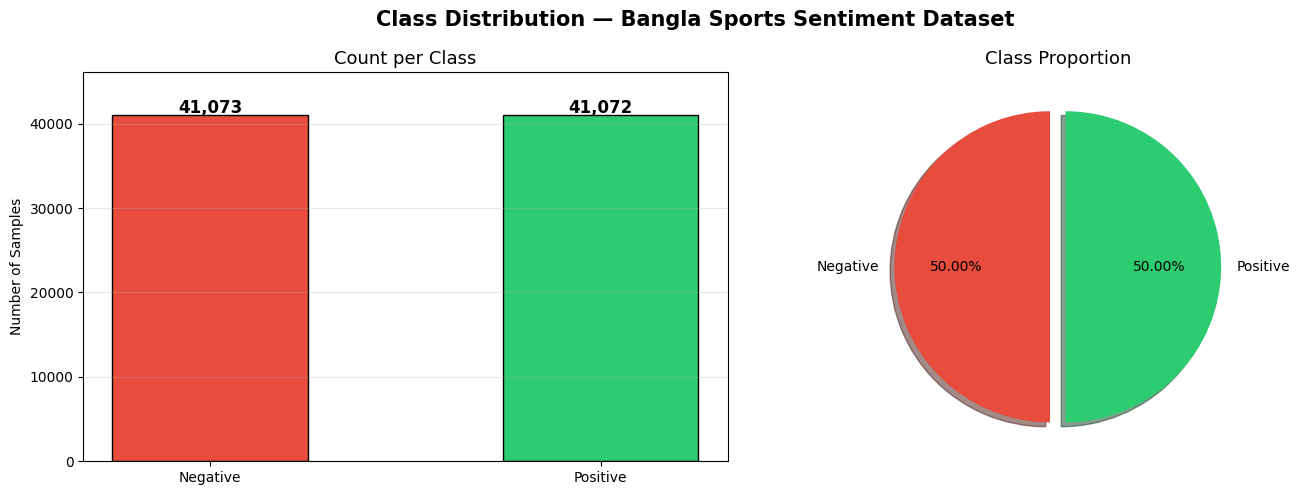

✅ Saved: fig1_class_distribution.png


In [8]:
# ── Plot 1: Class Distribution ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Class Distribution — Bangla Sports Sentiment Dataset', fontsize=15, fontweight='bold')

colors = ['#e74c3c', '#2ecc71']
labels = ['Negative', 'Positive']
counts = df['Category'].value_counts()

# Bar chart
axes[0].bar(labels, [counts['Negative'], counts['Positive']], color=colors, width=0.5, edgecolor='black')
axes[0].set_title('Count per Class', fontsize=13)
axes[0].set_ylabel('Number of Samples')
for i, v in enumerate([counts['Negative'], counts['Positive']]):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold', fontsize=12)
axes[0].set_ylim(0, max(counts) + 5000)
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(
    [counts['Negative'], counts['Positive']],
    labels=labels,
    autopct='%1.2f%%',
    colors=colors,
    startangle=90,
    explode=(0.05, 0.05),
    shadow=True
)
axes[1].set_title('Class Proportion', fontsize=13)

plt.tight_layout()
plt.savefig('fig1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: fig1_class_distribution.png')

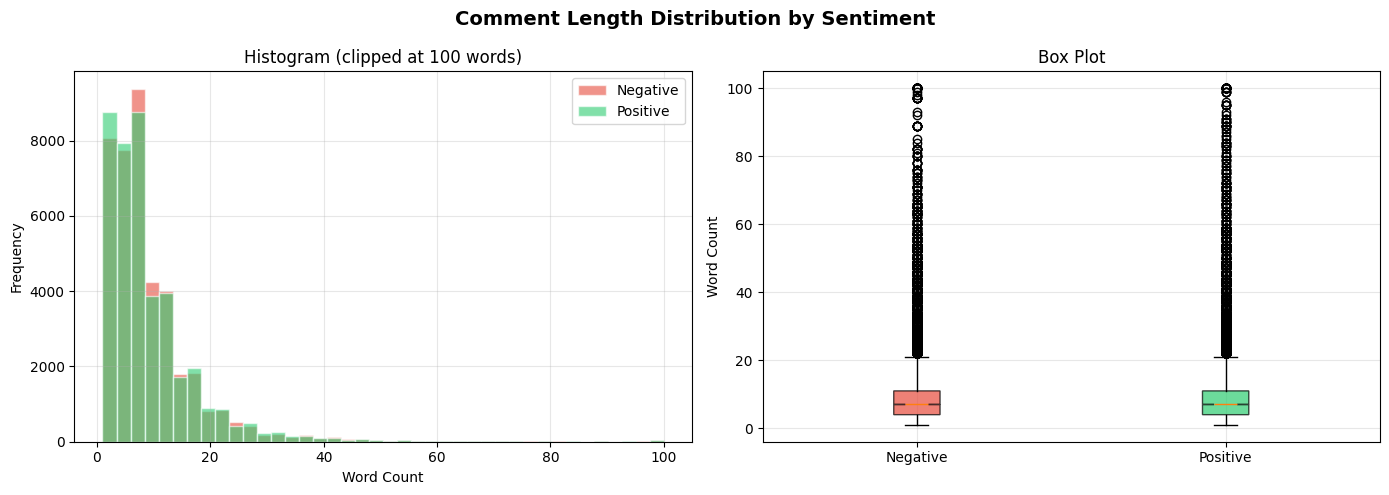

Avg length (Negative): 9.3 words
Avg length (Positive): 9.3 words


In [9]:
# ── Plot 2: Comment Length Distribution ───────────────────────────────────────
df['comment_len'] = df['Comment'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comment Length Distribution by Sentiment', fontsize=14, fontweight='bold')

# By class
for cat, color in zip(['Negative', 'Positive'], colors):
    subset = df[df['Category'] == cat]['comment_len']
    axes[0].hist(subset.clip(upper=100), bins=40, alpha=0.6, color=color, label=cat, edgecolor='white')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Histogram (clipped at 100 words)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot
data_to_plot = [
    df[df['Category'] == 'Negative']['comment_len'].clip(upper=100),
    df[df['Category'] == 'Positive']['comment_len'].clip(upper=100)
]
bp = axes[1].boxplot(data_to_plot, labels=['Negative', 'Positive'], patch_artist=True, notch=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_ylabel('Word Count')
axes[1].set_title('Box Plot')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig2_comment_length.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Avg length (Negative): {df[df["Category"]=="Negative"]["comment_len"].mean():.1f} words')
print(f'Avg length (Positive): {df[df["Category"]=="Positive"]["comment_len"].mean():.1f} words')

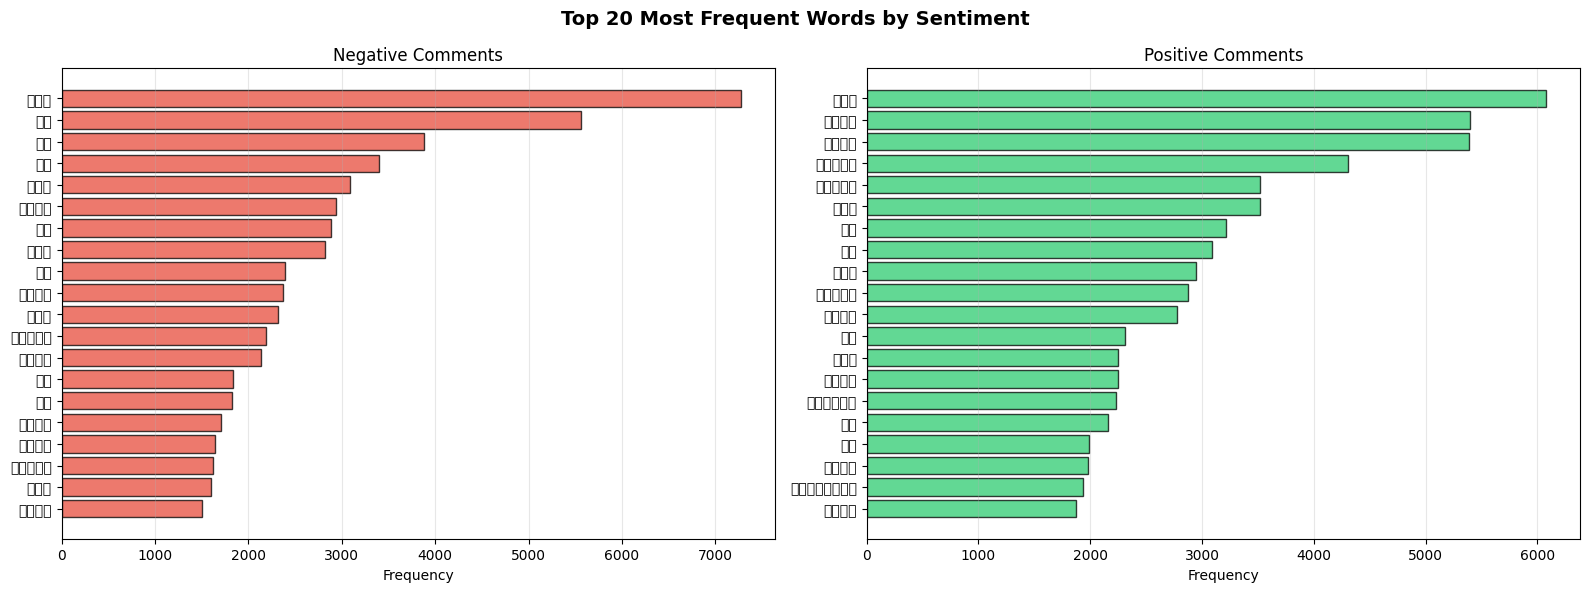

In [10]:
# ── Plot 3: Top 20 Most Frequent Words per Class ──────────────────────────────
def get_top_words(texts, n=20):
    words = []
    for text in texts:
        words.extend(str(text).split())
    return Counter(words).most_common(n)

neg_words = get_top_words(df[df['Category'] == 'Negative']['Comment'])
pos_words = get_top_words(df[df['Category'] == 'Positive']['Comment'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top 20 Most Frequent Words by Sentiment', fontsize=14, fontweight='bold')

for ax, word_list, color, title in zip(
    axes,
    [neg_words, pos_words],
    ['#e74c3c', '#2ecc71'],
    ['Negative Comments', 'Positive Comments']
):
    words, freqs = zip(*word_list)
    y_pos = np.arange(len(words))
    ax.barh(y_pos, freqs, color=color, alpha=0.75, edgecolor='black')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(words, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel('Frequency')
    ax.set_title(title, fontsize=12)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('fig3_top_words.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Data Preparation for BERT

In [11]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
MODEL_NAME   = 'sagorsarker/bangla-bert-base'
MAX_LEN      = 128
BATCH_SIZE   = 16  # Changed from 32 to 16
EPOCHS       = 8   # Changed from 5 to 8
LR           = 1e-5  # Changed from 2e-5 to 1e-5
DROPOUT      = 0.3
WARMUP_RATIO = 0.1

print('── Hyperparameters ──────────────────────────────')
print(f'  Model        : {MODEL_NAME}')
print(f'  Max Length   : {MAX_LEN}')
print(f'  Batch Size   : {BATCH_SIZE}')
print(f'  Epochs       : {EPOCHS}')
print(f'  Learning Rate: {LR}')
print(f'  Dropout      : {DROPOUT}')

── Hyperparameters ──────────────────────────────
  Model        : sagorsarker/bangla-bert-base
  Max Length   : 128
  Batch Size   : 16
  Epochs       : 8
  Learning Rate: 1e-05
  Dropout      : 0.3


In [12]:
# ── Train / Val / Test Split  (70 / 15 / 15) ─────────────────────────────────
train_df, temp_df = train_test_split(
    df[['Comment', 'label']], test_size=0.30,
    random_state=SEED, stratify=df['label']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50,
    random_state=SEED, stratify=temp_df['label']
)

print('── Dataset Split ────────────────────────────────')
print(f'  Train  : {len(train_df):,} ({len(train_df)/len(df)*100:.1f}%)')
print(f'  Val    : {len(val_df):,} ({len(val_df)/len(df)*100:.1f}%)')
print(f'  Test   : {len(test_df):,} ({len(test_df)/len(df)*100:.1f}%)')

── Dataset Split ────────────────────────────────
  Train  : 57,501 (70.0%)
  Val    : 12,322 (15.0%)
  Test   : 12,322 (15.0%)


In [13]:
# ── BERT Tokenizer ────────────────────────────────────────────────────────────
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
print(f'✅ Tokenizer loaded: {MODEL_NAME}')

# Quick test
sample = "বাংলাদেশের ক্রিকেট দল অসাধারণ খেলেছে!"
enc = tokenizer(sample, return_tensors='pt')
print(f'   Sample tokens: {tokenizer.convert_ids_to_tokens(enc["input_ids"][0])}')

vocab.txt: 0.00B [00:00, ?B/s]

✅ Tokenizer loaded: sagorsarker/bangla-bert-base
   Sample tokens: ['[CLS]', 'বাংলাদেশের', 'ক্রিকেট', 'দল', 'অসাধারণ', 'খেলেছে', '!', '[SEP]']


In [14]:
# ── PyTorch Dataset ───────────────────────────────────────────────────────────
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts.reset_index(drop=True)
        self.labels    = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = self.tokenizer(
            text,
            max_length      = self.max_len,
            padding         = 'max_length',
            truncation      = True,
            return_tensors  = 'pt',
            add_special_tokens = True
        )
        return {
            'input_ids'      : encoding['input_ids'].squeeze(0),
            'attention_mask' : encoding['attention_mask'].squeeze(0),
            'token_type_ids' : encoding['token_type_ids'].squeeze(0),
            'label'          : torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Create datasets
train_dataset = SentimentDataset(train_df['Comment'], train_df['label'], tokenizer, MAX_LEN)
val_dataset   = SentimentDataset(val_df['Comment'],   val_df['label'],   tokenizer, MAX_LEN)
test_dataset  = SentimentDataset(test_df['Comment'],  test_df['label'],  tokenizer, MAX_LEN)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'✅ DataLoaders ready')
print(f'   Train batches : {len(train_loader)}')
print(f'   Val batches   : {len(val_loader)}')
print(f'   Test batches  : {len(test_loader)}')

✅ DataLoaders ready
   Train batches : 3594
   Val batches   : 771
   Test batches  : 771


## 5. Model Architecture

In [15]:
# ── BanglaBERT Sentiment Classifier ──────────────────────────────────────────
class BanglaBertSentiment(nn.Module):
    """
    Bangla BERT + custom classification head:
      [CLS] → LayerNorm → Dropout → FC(768→256) → GELU → Dropout → FC(256→2)
    """
    def __init__(self, bert_model_name, num_classes=2, dropout=0.3):
        super(BanglaBertSentiment, self).__init__()
        self.bert    = BertModel.from_pretrained(bert_model_name)
        hidden_size  = self.bert.config.hidden_size  # 768

        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, input_ids, attention_mask, token_type_ids):
        outputs = self.bert(
            input_ids       = input_ids,
            attention_mask  = attention_mask,
            token_type_ids  = token_type_ids
        )
        pooled = outputs.pooler_output   # [CLS] representation
        logits = self.classifier(pooled)
        return logits


model = BanglaBertSentiment(MODEL_NAME, dropout=DROPOUT)
model = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('── Model Summary ─────────────────────────────────────')
print(f'  Total Parameters     : {total_params:,}')
print(f'  Trainable Parameters : {trainable_params:,}')
print(f'  Architecture         : Bangla-BERT + LayerNorm + 2×FC')

config.json:   0%|          | 0.00/491 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/660M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


── Model Summary ─────────────────────────────────────
  Total Parameters     : 164,595,458
  Trainable Parameters : 164,595,458
  Architecture         : Bangla-BERT + LayerNorm + 2×FC


## 6. Training Setup

In [16]:
# ── Optimizer, Scheduler, Loss ────────────────────────────────────────────────
total_steps   = len(train_loader) * EPOCHS
warmup_steps  = int(total_steps * WARMUP_RATIO)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps
)
criterion = nn.CrossEntropyLoss()

print(f'✅ Optimizer  : AdamW (lr={LR}, weight_decay=0.01)')
print(f'   Scheduler  : Linear warmup → decay')
print(f'   Loss       : CrossEntropyLoss')
print(f'   Total steps: {total_steps:,} | Warmup: {warmup_steps:,}')

✅ Optimizer  : AdamW (lr=1e-05, weight_decay=0.01)
   Scheduler  : Linear warmup → decay
   Loss       : CrossEntropyLoss
   Total steps: 28,752 | Warmup: 2,875


In [17]:
# ── Train & Evaluate Functions ────────────────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion, scheduler, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in tqdm(loader, desc='  Training', leave=False):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask, token_type_ids)
        loss   = criterion(logits, labels)

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    return total_loss / len(loader), correct / total * 100


@torch.no_grad()
def evaluate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    for batch in tqdm(loader, desc='  Evaluating', leave=False):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels         = batch['label'].to(device)

        logits = model(input_ids, attention_mask, token_type_ids)
        loss   = criterion(logits, labels)

        total_loss += loss.item()
        probs  = torch.softmax(logits, dim=1)[:, 1]
        preds  = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    return total_loss / len(loader), correct / total * 100, all_preds, all_labels, all_probs

## 7. Training Loop

In [ ]:
# ── Main Training Loop ────────────────────────────────────────────────────────
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  []
}

best_val_acc  = 0.0
best_val_f1   = 0.0
patience      = 2
no_improve    = 0
start_time    = time.time()

print('=' * 65)
print('  🚀 Training BanglaBERT Sentiment Classifier')
print('=' * 65)

for epoch in range(1, EPOCHS + 1):
    print(f'\n  Epoch {epoch}/{EPOCHS}')
    print('  ' + '-' * 60)

    t_loss, t_acc = train_epoch(model, train_loader, optimizer, criterion, scheduler, device)
    v_loss, v_acc, v_preds, v_labels, v_probs = evaluate_epoch(model, val_loader, criterion, device)

    v_f1 = f1_score(v_labels, v_preds, average='weighted')

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)

    print(f'  Train  → Loss: {t_loss:.4f} | Acc: {t_acc:.2f}%')
    print(f'  Val    → Loss: {v_loss:.4f} | Acc: {v_acc:.2f}% | F1: {v_f1:.4f}')

    if v_acc > best_val_acc:
        best_val_acc = v_acc
        best_val_f1  = v_f1
        torch.save(model.state_dict(), 'best_bangla_bert.pth')
        print(f'  ✅ Best model saved! (Val Acc: {best_val_acc:.2f}%)')
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f'  ⚠️  Early stopping triggered at epoch {epoch}')
            break

elapsed = time.time() - start_time
print('\n' + '=' * 65)
print(f'  ✅ Training Done | Time: {elapsed//60:.0f}m {elapsed%60:.0f}s')
print(f'  Best Val Acc: {best_val_acc:.2f}% | Best Val F1: {best_val_f1:.4f}')
print('=' * 65)

  🚀 Training BanglaBERT Sentiment Classifier

  Epoch 1/8
  ------------------------------------------------------------


  Training:   0%|          | 0/3594 [00:00<?, ?it/s]

  Evaluating:   0%|          | 0/771 [00:00<?, ?it/s]

  Train  → Loss: 0.5664 | Acc: 69.73%
  Val    → Loss: 0.4919 | Acc: 76.68% | F1: 0.7664
  ✅ Best model saved! (Val Acc: 76.68%)

  Epoch 2/8
  ------------------------------------------------------------


  Training:   0%|          | 0/3594 [00:00<?, ?it/s]

...

  Train  → Loss: 0.2255 | Acc: 91.85%
  Val    → Loss: 0.6335 | Acc: 81.68% | F1: 0.8168
  ✅ Best model saved! (Val Acc: 81.68%)

  Epoch 6/8
  ------------------------------------------------------------


  Training:   0%|          | 0/3594 [00:00<?, ?it/s]

  Evaluating:   0%|          | 0/771 [00:00<?, ?it/s]

  Train  → Loss: 0.1937 | Acc: 93.50%
  Val    → Loss: 0.6959 | Acc: 81.88% | F1: 0.8188
  ✅ Best model saved! (Val Acc: 81.88%)

  Epoch 7/8
  ------------------------------------------------------------


  Training:   0%|          | 0/3594 [00:00<?, ?it/s]

## 8. Training Curves

In [ ]:
# ── Plot 4: Training Curves ───────────────────────────────────────────────────
epochs_ran = len(history['train_loss'])
x = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('BanglaBERT Training Curves', fontsize=14, fontweight='bold')

# Loss
axes[0].plot(x, history['train_loss'], 'b-o', label='Train Loss', linewidth=2, markersize=7)
axes[0].plot(x, history['val_loss'],   'r-s', label='Val Loss',   linewidth=2, markersize=7)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss per Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xticks(list(x))

# Accuracy
axes[1].plot(x, history['train_acc'], 'b-o', label='Train Acc', linewidth=2, markersize=7)
axes[1].plot(x, history['val_acc'],   'r-s', label='Val Acc',   linewidth=2, markersize=7)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy per Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xticks(list(x))

plt.tight_layout()
plt.savefig('fig4_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: fig4_training_curves.png')

## 9. Final Evaluation on Test Set

In [ ]:
# ── Load Best Model & Evaluate on Test Set ────────────────────────────────────
model.load_state_dict(torch.load('best_bangla_bert.pth', map_location=device))
print('✅ Best model loaded')

_, test_acc, test_preds, test_labels, test_probs = evaluate_epoch(model, test_loader, criterion, device)

test_prec = precision_score(test_labels, test_preds, average='weighted')
test_rec  = recall_score(test_labels, test_preds, average='weighted')
test_f1   = f1_score(test_labels, test_preds, average='weighted')
test_auc  = roc_auc_score(test_labels, test_probs)

print('\n' + '=' * 55)
print('       📊 FINAL TEST SET RESULTS')
print('=' * 55)
print(f'  Accuracy  : {test_acc:.4f}%')
print(f'  Precision : {test_prec:.4f}')
print(f'  Recall    : {test_rec:.4f}')
print(f'  F1-Score  : {test_f1:.4f}')
print(f'  ROC-AUC   : {test_auc:.4f}')
print('=' * 55)

In [ ]:
# ── Detailed Classification Report ────────────────────────────────────────────
print('\n── Classification Report ──────────────────────────────')
print(classification_report(
    test_labels, test_preds,
    target_names=['Negative', 'Positive']
))

In [ ]:
# ── Plot 5: Confusion Matrix ──────────────────────────────────────────────────
cm = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrix — Test Set', fontsize=14, fontweight='bold')

class_names = ['Negative', 'Positive']

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2%'],
    ['Raw Counts', 'Normalized (%)' ]
):
    sns.heatmap(
        data, annot=True, fmt=fmt, cmap='Blues',
        xticklabels=class_names, yticklabels=class_names,
        ax=ax, linewidths=0.5, linecolor='gray'
    )
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_title(title, fontsize=12)

plt.tight_layout()
plt.savefig('fig5_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: fig5_confusion_matrix.png')

In [ ]:
# ── Plot 6: ROC Curve ─────────────────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(test_labels, test_probs)
auc_score = roc_auc_score(test_labels, test_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.15, color='darkorange')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — BanglaBERT Sentiment Classifier', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.savefig('fig6_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ ROC-AUC: {auc_score:.4f} | Saved: fig6_roc_curve.png')

In [ ]:
# ── Plot 7: Per-Class Metrics Bar Chart ───────────────────────────────────────
report = classification_report(
    test_labels, test_preds,
    target_names=['Negative', 'Positive'],
    output_dict=True
)

metrics     = ['precision', 'recall', 'f1-score']
neg_scores  = [report['Negative'][m] for m in metrics]
pos_scores  = [report['Positive'][m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))
bars1 = ax.bar(x - width/2, neg_scores, width, label='Negative', color='#e74c3c', alpha=0.85, edgecolor='black')
bars2 = ax.bar(x + width/2, pos_scores, width, label='Positive', color='#2ecc71', alpha=0.85, edgecolor='black')

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Per-Class Precision / Recall / F1-Score', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['Precision', 'Recall', 'F1-Score'], fontsize=11)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig7_perclass_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: fig7_perclass_metrics.png')

In [ ]:
# ── Plot 8: Prediction Probability Distribution ───────────────────────────────
test_probs_arr = np.array(test_probs)
test_labels_arr = np.array(test_labels)

plt.figure(figsize=(10, 5))
plt.hist(test_probs_arr[test_labels_arr == 1], bins=50, alpha=0.6,
         color='#2ecc71', label='True Positive', edgecolor='white')
plt.hist(test_probs_arr[test_labels_arr == 0], bins=50, alpha=0.6,
         color='#e74c3c', label='True Negative', edgecolor='white')
plt.axvline(x=0.5, color='black', linestyle='--', linewidth=1.5, label='Decision Boundary (0.5)')
plt.xlabel('Predicted Probability (Positive class)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Prediction Probability Distribution', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.savefig('fig8_prob_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: fig8_prob_distribution.png')

In [ ]:
# ── Plot 9: Comprehensive Summary Dashboard ────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
fig.suptitle('BanglaBERT Sentiment Analysis — Full Result Dashboard', fontsize=16, fontweight='bold', y=1.01)

# 1. Training loss
ax1 = fig.add_subplot(3, 3, 1)
ax1.plot(range(1, epochs_ran+1), history['train_loss'], 'b-o', linewidth=2)
ax1.plot(range(1, epochs_ran+1), history['val_loss'],   'r-s', linewidth=2)
ax1.set_title('Train / Val Loss'); ax1.legend(['Train', 'Val']); ax1.grid(alpha=0.3)

# 2. Training accuracy
ax2 = fig.add_subplot(3, 3, 2)
ax2.plot(range(1, epochs_ran+1), history['train_acc'], 'b-o', linewidth=2)
ax2.plot(range(1, epochs_ran+1), history['val_acc'],   'r-s', linewidth=2)
ax2.set_title('Train / Val Accuracy (%)'); ax2.legend(['Train', 'Val']); ax2.grid(alpha=0.3)

# 3. Class distribution
ax3 = fig.add_subplot(3, 3, 3)
ax3.bar(['Negative', 'Positive'], [counts['Negative'], counts['Positive']], color=colors)
ax3.set_title('Class Distribution'); ax3.grid(axis='y', alpha=0.3)

# 4. Confusion matrix
ax4 = fig.add_subplot(3, 3, 4)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'], ax=ax4)
ax4.set_title('Confusion Matrix')

# 5. ROC curve
ax5 = fig.add_subplot(3, 3, 5)
ax5.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC={auc_score:.3f}')
ax5.plot([0,1],[0,1],'--',color='navy')
ax5.fill_between(fpr, tpr, alpha=0.15, color='darkorange')
ax5.set_title('ROC Curve'); ax5.legend(); ax5.grid(alpha=0.3)

# 6. Per-class F1
ax6 = fig.add_subplot(3, 3, 6)
ax6.bar(['Negative', 'Positive'],
        [report['Negative']['f1-score'], report['Positive']['f1-score']],
        color=colors, edgecolor='black')
ax6.set_title('Per-Class F1-Score'); ax6.set_ylim(0, 1.1); ax6.grid(axis='y', alpha=0.3)

# 7. Final metrics table
ax7 = fig.add_subplot(3, 3, 7)
ax7.axis('off')
table_data = [
    ['Metric', 'Score'],
    ['Accuracy',  f'{test_acc:.2f}%'],
    ['Precision', f'{test_prec:.4f}'],
    ['Recall',    f'{test_rec:.4f}'],
    ['F1-Score',  f'{test_f1:.4f}'],
    ['ROC-AUC',   f'{test_auc:.4f}'],
    ['Best Val',  f'{best_val_acc:.2f}%'],
]
table = ax7.table(cellText=table_data[1:], colLabels=table_data[0],
                  cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(11)
table[(0, 0)].set_facecolor('#3498db')
table[(0, 1)].set_facecolor('#3498db')
for i in range(1, len(table_data)):
    table[(i, 0)].set_facecolor('#ecf0f1')
    table[(i, 1)].set_facecolor('#d5f5e3')
ax7.set_title('Summary Metrics', fontsize=11, fontweight='bold')

# 8. Probability distribution
ax8 = fig.add_subplot(3, 3, 8)
ax8.hist(test_probs_arr[test_labels_arr==1], bins=40, alpha=0.6, color='#2ecc71', label='True Pos')
ax8.hist(test_probs_arr[test_labels_arr==0], bins=40, alpha=0.6, color='#e74c3c', label='True Neg')
ax8.axvline(0.5, color='black', linestyle='--')
ax8.set_title('Probability Distribution'); ax8.legend(); ax8.grid(alpha=0.3)

# 9. Train/Val gap (overfit analysis)
ax9 = fig.add_subplot(3, 3, 9)
gap = [t - v for t, v in zip(history['train_acc'], history['val_acc'])]
ax9.bar(range(1, epochs_ran+1), gap, color=['#e67e22' if g > 3 else '#27ae60' for g in gap])
ax9.axhline(0, color='black', linewidth=0.8)
ax9.set_title('Train–Val Accuracy Gap (Overfit Check)')
ax9.set_xlabel('Epoch'); ax9.set_ylabel('Gap (%)')
ax9.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig9_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: fig9_dashboard.png')

## 10. Error Analysis

In [ ]:
# ── Misclassified Samples Analysis ────────────────────────────────────────────
test_df_reset = test_df.reset_index(drop=True)
test_df_reset['predicted'] = test_preds
test_df_reset['probability'] = test_probs
test_df_reset['true_label'] = test_labels

misclassified = test_df_reset[test_df_reset['label'] != test_df_reset['predicted']]

print(f'Total misclassified: {len(misclassified):,} / {len(test_df_reset):,}')
print(f'Error rate: {len(misclassified)/len(test_df_reset)*100:.2f}%\n')

# FP and FN
false_pos = misclassified[misclassified['label'] == 0]  # Negative predicted as Positive
false_neg = misclassified[misclassified['label'] == 1]  # Positive predicted as Negative

print(f'False Positives (Neg→Pos): {len(false_pos):,}')
print(f'False Negatives (Pos→Neg): {len(false_neg):,}')

print('\n── Sample Misclassified Comments (False Positives) ──')
print(false_pos[['Comment', 'probability']].head(5).to_string(index=False))

print('\n── Sample Misclassified Comments (False Negatives) ──')
print(false_neg[['Comment', 'probability']].head(5).to_string(index=False))

## 11. Inference — Test on Custom Sentences

In [ ]:
# ── Inference Function ────────────────────────────────────────────────────────
@torch.no_grad()
def predict_sentiment(text, model, tokenizer, device, max_len=128):
    model.eval()
    encoding = tokenizer(
        text,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors='pt',
        add_special_tokens=True
    )
    input_ids      = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    token_type_ids = encoding['token_type_ids'].to(device)

    logits = model(input_ids, attention_mask, token_type_ids)
    probs  = torch.softmax(logits, dim=1)
    pred   = logits.argmax(dim=1).item()

    sentiment = 'Positive 😊' if pred == 1 else 'Negative 😞'
    confidence = probs[0][pred].item() * 100
    return sentiment, confidence


# Test examples
test_sentences = [
    "বাংলাদেশের ক্রিকেট দল অসাধারণ খেলেছে, গর্বিত!",
    "এই খেলোয়াড়গুলো একদম বাজে খেলছে, লজ্জাজনক।",
    "সাকিব আল হাসান আমাদের সেরা ক্রিকেটার!",
    "ফুটবল দলটা কোনো কাজের না, বরং না খেললেই ভালো।",
    "আজকের ম্যাচটা অনেক সুন্দর হয়েছে।"
]

print('── Custom Inference Results ──────────────────────────────')
print(f'{"Comment":<55} {"Sentiment":<18} {"Confidence"}')
print('─' * 90)
for sent in test_sentences:
    sentiment, confidence = predict_sentiment(sent, model, tokenizer, device)
    print(f'{sent[:54]:<55} {sentiment:<18} {confidence:.2f}%')

## 12. Final Summary

In [ ]:
print('\n' + '█' * 60)
print('  📊  BANGLA SPORTS SENTIMENT — THESIS RESULT SUMMARY')
print('█' * 60)
print(f'  Model         : sagorsarker/bangla-bert-base')
print(f'  Dataset Size  : {len(df):,}')
print(f'  Classes       : Negative ({counts["Negative"]:,}) | Positive ({counts["Positive"]:,})')
print(f'  Split         : 70% Train | 15% Val | 15% Test')
print(f'  Max Length    : {MAX_LEN} tokens')
print(f'  Batch Size    : {BATCH_SIZE}')
print(f'  Epochs Run    : {epochs_ran}')
print(f'  Optimizer     : AdamW (lr={LR})')
print('─' * 60)
print(f'  Test Accuracy : {test_acc:.2f}%')
print(f'  Precision     : {test_prec:.4f}')
print(f'  Recall        : {test_rec:.4f}')
print(f'  F1-Score      : {test_f1:.4f}')
print(f'  ROC-AUC       : {test_auc:.4f}')
print('█' * 60)
print('  Generated Figures:')
for i, name in enumerate([
    'Class Distribution',
    'Comment Length Analysis',
    'Top Frequent Words',
    'Training Curves (Loss & Accuracy)',
    'Confusion Matrix (Raw + Normalized)',
    'ROC Curve',
    'Per-Class Metrics',
    'Probability Distribution',
    'Full Dashboard'
], start=1):
    print(f'  fig{i}_... → {name}')
print('█' * 60)